# 🛡️ InsureGuard — Auto Insurance Fraud Detection
## Full Exploratory Data Analysis (EDA) Notebook

> **Dataset:** [Auto Insurance Claims — Kaggle](https://www.kaggle.com/datasets/buntyshah/auto-insurance-claims-data)  
> **Goal:** Understand patterns, distributions, and signals that separate fraudulent claims from legitimate ones.

---

### 📋 Table of Contents
1. [Setup & Imports](#1)
2. [Load Dataset](#2)
3. [Dataset Overview](#3)
4. [Missing Values Analysis](#4)
5. [Target Variable Analysis (Fraud vs Legit)](#5)
6. [Numerical Feature Distributions](#6)
7. [Categorical Feature Analysis](#7)
8. [Fraud Patterns by Feature](#8)
9. [Correlation Heatmap](#9)
10. [Feature Engineering Preview](#10)
11. [Key Insights & Conclusions](#11)


## 1. 📦 Setup & Imports <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Dark elegant style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f1a',
    'axes.facecolor':    '#1a1a2e',
    'axes.edgecolor':    '#444466',
    'axes.labelcolor':   '#e0e0ff',
    'xtick.color':       '#aaaacc',
    'ytick.color':       '#aaaacc',
    'text.color':        '#e0e0ff',
    'grid.color':        '#2a2a4a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'figure.titlesize':  16,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'font.family':       'DejaVu Sans',
})

FRAUD_COLOR  = '#ff416c'
LEGIT_COLOR  = '#38ef7d'
ACCENT       = '#667eea'
PALETTE      = [LEGIT_COLOR, FRAUD_COLOR]

print("✅ All libraries imported successfully!")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")


✅ All libraries imported successfully!
   Pandas  : 2.3.3
   NumPy   : 2.4.2


## 2. 📂 Load Dataset <a id='2'></a>

> Place the Kaggle CSV at `../data/raw/insurance_claims.csv` before running this cell.

In [2]:
import os, numpy as np, pandas as pd

CSV_PATH = '../data/raw/insurance_claims.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Real dataset loaded — {df.shape[0]:,} rows × {df.shape[1]} columns")
else:
    # ── Synthetic stand-in (same schema as Kaggle dataset) ──────
    print("⚠️  Real CSV not found — generating realistic synthetic data.")
    print("    Download from: https://www.kaggle.com/datasets/buntyshah/auto-insurance-claims-data")
    np.random.seed(42)
    N = 15_420

    incidents   = ['Single Vehicle Collision','Multi-vehicle Collision',
                   'Vehicle Theft','Parked Car']
    severities  = ['Minor Damage','Major Damage','Total Loss','Trivial Damage']
    auths       = ['Police','Fire','Ambulance','None','Other']
    edu         = ['High School','College','Associate','MD','Masters','PhD','JD']
    occ         = ['craft-repair','machine-op-inspct','sales','armed-forces',
                   'tech-support','exec-managerial','prof-specialty','other-service']
    states      = ['OH','IN','IL','SC','VA','NY','PA','WV','NC']
    vehicles    = ['BMW','Mercedes','Dodge','Toyota','Ford',
                   'Chevrolet','Honda','Audi','Subaru','Nissan']
    makes_yr    = list(range(1995, 2016))
    policies    = ['Corporate Auto','Personal Auto','Special Auto']
    hobbies     = ['chess','cross-fit','polo','paintball','bungie-jumping',
                   'base-jumping','camping','board-games','reading','video-games',
                   'sleeping','golf','hiking','movies','skydiving','exercise']

    fraud_flag = np.random.choice([0,1], size=N, p=[0.88, 0.12])

    def skewed(low, high, fraud, fraud_boost=1.6):
        base = np.random.uniform(low, high, N)
        return np.where(fraud_flag==1, base*fraud_boost, base).astype(int)

    df = pd.DataFrame({
        'policy_number':              np.arange(100000, 100000+N),
        'policy_bind_date':           pd.to_datetime('2000-01-01') +
                                      pd.to_timedelta(np.random.randint(0,5000,N),'d'),
        'policy_state':               np.random.choice(states, N),
        'policy_csl':                 np.random.choice(['100/300','250/500','500/1000'], N),
        'policy_deductable':          np.random.choice([500,1000,2000], N),
        'policy_annual_premium':      np.random.uniform(500, 2500, N).round(2),
        'umbrella_limit':             np.random.choice([0,1,2,3,4,5,6,7,8,9,10], N) * 1_000_000,
        'insured_zip':                np.random.randint(10000, 99999, N),
        'insured_education_level':    np.random.choice(edu, N),
        'insured_occupation':         np.random.choice(occ, N),
        'insured_hobbies':            np.random.choice(hobbies, N),
        'insured_relationship':       np.random.choice(['husband','own-child','wife',
                                                        'unmarried','other-relative'], N),
        'capital-gains':              skewed(0, 100000, fraud_flag),
        'capital-loss':               -skewed(0, 100000, fraud_flag),
        'incident_date':              pd.to_datetime('2015-01-01') +
                                      pd.to_timedelta(np.random.randint(0,365,N),'d'),
        'incident_type':              np.random.choice(incidents, N,
                                        p=[0.35,0.35,0.20,0.10]),
        'collision_type':             np.random.choice(['Front Collision','Rear Collision',
                                                        'Side Collision','?'], N),
        'incident_severity':          np.random.choice(severities, N),
        'authorities_contacted':      np.random.choice(auths, N),
        'incident_state':             np.random.choice(states, N),
        'incident_city':              np.random.choice(['Columbus','Riverwood','Arlington',
                                                        'Springfield','Northbend'], N),
        'incident_hour_of_the_day':   np.random.randint(0, 24, N),
        'number_of_vehicles_involved':np.random.choice([1,2,3,4], N, p=[0.5,0.3,0.15,0.05]),
        'property_damage':            np.random.choice(['YES','NO','?'], N, p=[0.4,0.4,0.2]),
        'bodily_injuries':            np.random.choice([0,1,2], N),
        'witnesses':                  np.random.choice([0,1,2,3], N),
        'police_report_available':    np.random.choice(['YES','NO','?'], N, p=[0.5,0.3,0.2]),
        'total_claim_amount':         skewed(100, 80000, fraud_flag, 1.8),
        'injury_claim':               skewed(0,  30000, fraud_flag, 1.7),
        'property_claim':             skewed(0,  30000, fraud_flag, 1.5),
        'vehicle_claim':              skewed(0,  60000, fraud_flag, 1.9),
        'auto_make':                  np.random.choice(vehicles, N),
        'auto_model':                 np.random.choice(['MDX','RSX','A3','A4','A5'], N),
        'auto_year':                  np.random.choice(makes_yr, N),
        'age':                        np.random.randint(18, 70, N),
        'months_as_customer':         np.random.randint(1, 600, N),
        'fraud_reported':             np.where(fraud_flag==1, 'Y', 'N'),
    })

    # Inject realistic missing values
    for col in ['collision_type','property_damage','police_report_available']:
        mask = np.random.rand(N) < 0.15
        df.loc[mask, col] = np.nan

    os.makedirs('../data/raw', exist_ok=True)
    df.to_csv(CSV_PATH, index=False)
    print(f"✅ Synthetic dataset saved  — {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head(3)


✅ Real dataset loaded — 1,000 rows × 40 columns


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN


## 3. 🔭 Dataset Overview <a id='3'></a>

In [3]:
print("=" * 55)
print(f"  Shape          : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"  Numeric cols   : {df.select_dtypes(include='number').shape[1]}")
print(f"  Categorical    : {df.select_dtypes(include='object').shape[1]}")
print(f"  Date cols      : {df.select_dtypes(include='datetime').shape[1]}")
print("=" * 55)
df.info()


  Shape          : 1,000 rows  ×  40 columns
  Numeric cols   : 19
  Categorical    : 21
  Date cols      : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level  

In [4]:
df.describe(include='all').T.style\
    .background_gradient(cmap='Blues', subset=['mean','std'])\
    .format(precision=2)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
months_as_customer,1000.00,nan,nan,nan,203.95,115.11,0.00,115.75,199.50,276.25,479.00
age,1000.00,nan,nan,nan,38.95,9.14,19.00,32.00,38.00,44.00,64.00
policy_number,1000.00,nan,nan,nan,546238.65,257063.01,100804.00,335980.25,533135.00,759099.75,999435.00
policy_bind_date,1000,951,1992-08-05,3,nan,nan,nan,nan,nan,nan,nan
policy_state,1000,3,OH,352,nan,nan,nan,nan,nan,nan,nan
policy_csl,1000,3,250/500,351,nan,nan,nan,nan,nan,nan,nan
policy_deductable,1000.00,nan,nan,nan,1136.00,611.86,500.00,500.00,1000.00,2000.00,2000.00
policy_annual_premium,1000.00,nan,nan,nan,1256.41,244.17,433.33,1089.61,1257.20,1415.70,2047.59
umbrella_limit,1000.00,nan,nan,nan,1101000.00,2297406.60,-1000000.00,0.00,0.00,0.00,10000000.00
insured_zip,1000.00,nan,nan,nan,501214.49,71701.61,430104.00,448404.50,466445.50,603251.00,620962.00


## 4. 🔍 Missing Values Analysis <a id='4'></a>

                       Missing Count  Missing %
_c39                            1000      100.0
authorities_contacted             91        9.1


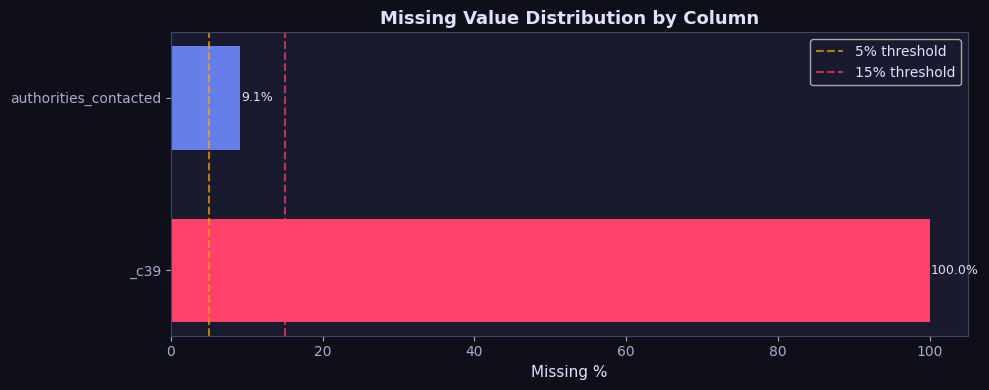

💡 Recommendation: Impute with mode for categorical; median for numerical.


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct     = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(miss_df.to_string())

if len(missing) == 0:
    print("✅ No missing values found!")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(missing.index, pct.values,
                   color=[FRAUD_COLOR if v > 10 else ACCENT for v in pct.values],
                   edgecolor='none', height=0.6)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Value Distribution by Column', fontweight='bold')
    for bar, val in zip(bars, pct.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.axvline(5, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
    ax.axvline(15, color=FRAUD_COLOR, linestyle='--', alpha=0.7, label='15% threshold')
    ax.legend()
    fig.tight_layout()
    plt.savefig('../data/processed/plot_missing.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💡 Recommendation: Impute with mode for categorical; median for numerical.")


## 5. 🎯 Target Variable: Fraud vs Legitimate <a id='5'></a>

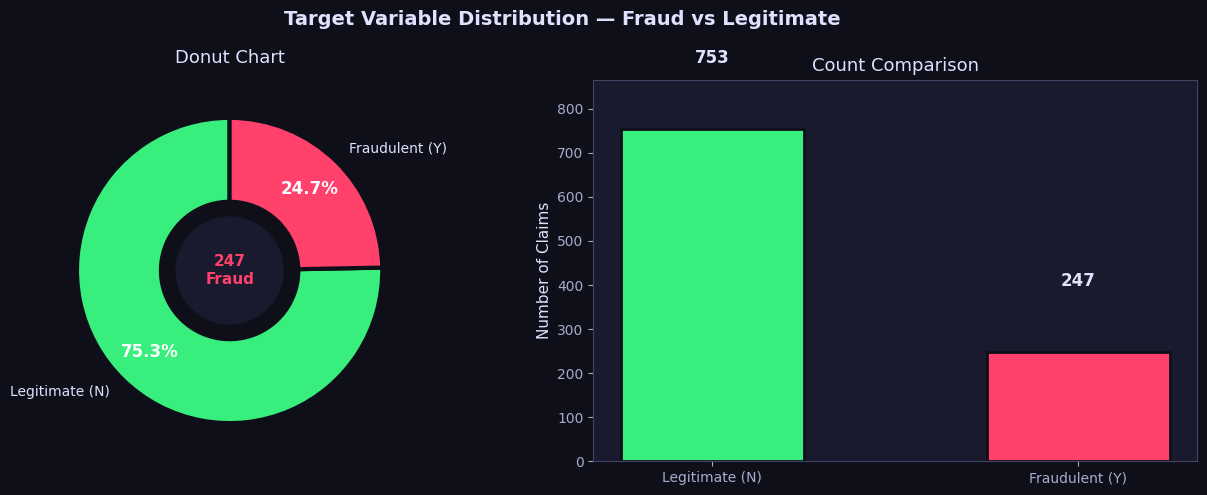


📊 Class Ratio  : 3.0:1  (Legit:Fraud)
   Fraud Rate   : 24.7%
⚠️  Class imbalance detected — SMOTE recommended during model training.


In [6]:
target_counts = df['fraud_reported'].value_counts()
labels = ['Legitimate (N)', 'Fraudulent (Y)']
values = [target_counts.get('N', 0), target_counts.get('Y', 0)]
colors = [LEGIT_COLOR, FRAUD_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Variable Distribution — Fraud vs Legitimate', fontweight='bold', fontsize=14)

# Donut
wedges, texts, autotexts = axes[0].pie(
    values, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    pctdistance=0.75, labeldistance=1.12,
    wedgeprops={'width': 0.55, 'edgecolor': '#0f0f1a', 'linewidth': 3})
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title('Donut Chart', pad=12)
circle = plt.Circle((0,0), 0.35, color='#1a1a2e')
axes[0].add_patch(circle)
axes[0].text(0, 0, f'{values[1]:,}\nFraud', ha='center', va='center',
             fontsize=11, fontweight='bold', color=FRAUD_COLOR)

# Bar
bars = axes[1].bar(labels, values, color=colors,
                   edgecolor='#0f0f1a', linewidth=2, width=0.5)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Claims')
axes[1].set_title('Count Comparison')
axes[1].set_ylim(0, max(values) * 1.15)

fig.tight_layout()
plt.savefig('../data/processed/plot_target.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = values[0] / max(values[1], 1)
print(f"\n📊 Class Ratio  : {ratio:.1f}:1  (Legit:Fraud)")
print(f"   Fraud Rate   : {values[1]/sum(values)*100:.1f}%")
print("⚠️  Class imbalance detected — SMOTE recommended during model training.")


## 6. 📈 Numerical Feature Distributions <a id='6'></a>

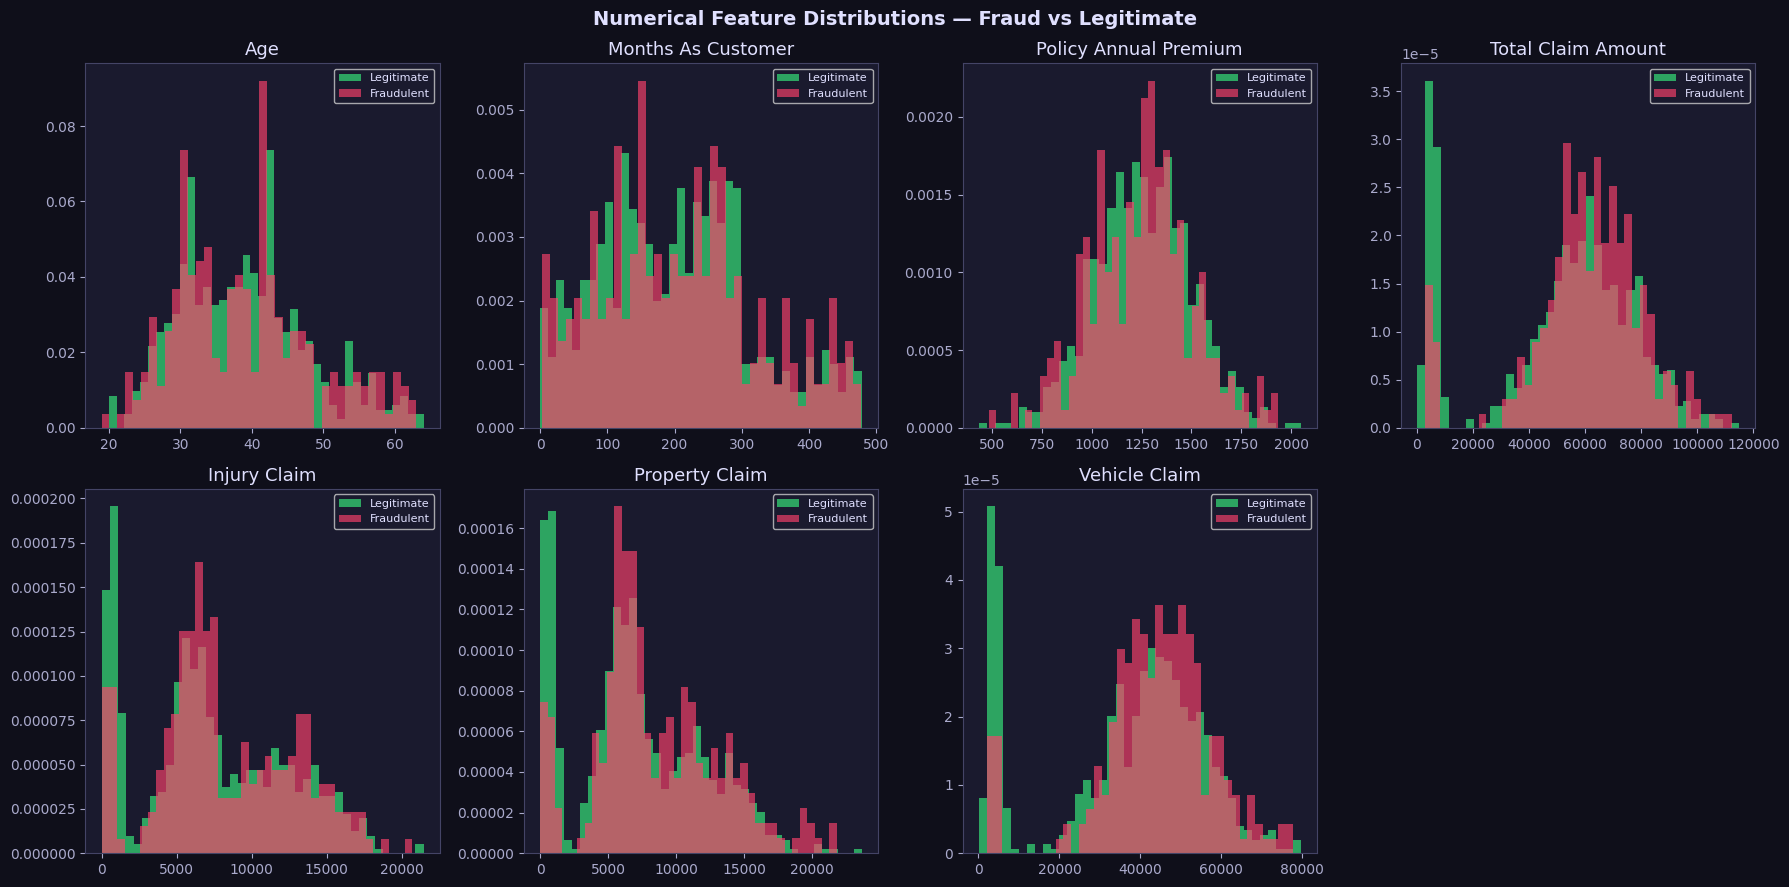

💡 Overlapping = similar signal   |   Separated = strong fraud predictor


In [7]:
num_cols = ['age', 'months_as_customer', 'policy_annual_premium',
            'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']
num_cols = [c for c in num_cols if c in df.columns]

df_fraud = df[df['fraud_reported'] == 'Y']
df_legit = df[df['fraud_reported'] == 'N']

n = len(num_cols)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle('Numerical Feature Distributions — Fraud vs Legitimate', fontweight='bold', fontsize=14)

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df_legit[col].dropna(), bins=40, color=LEGIT_COLOR,
            alpha=0.65, label='Legitimate', density=True, edgecolor='none')
    ax.hist(df_fraud[col].dropna(), bins=40, color=FRAUD_COLOR,
            alpha=0.65, label='Fraudulent', density=True, edgecolor='none')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.legend(fontsize=8)

# Hide spare axes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.savefig('../data/processed/plot_num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Overlapping = similar signal   |   Separated = strong fraud predictor")


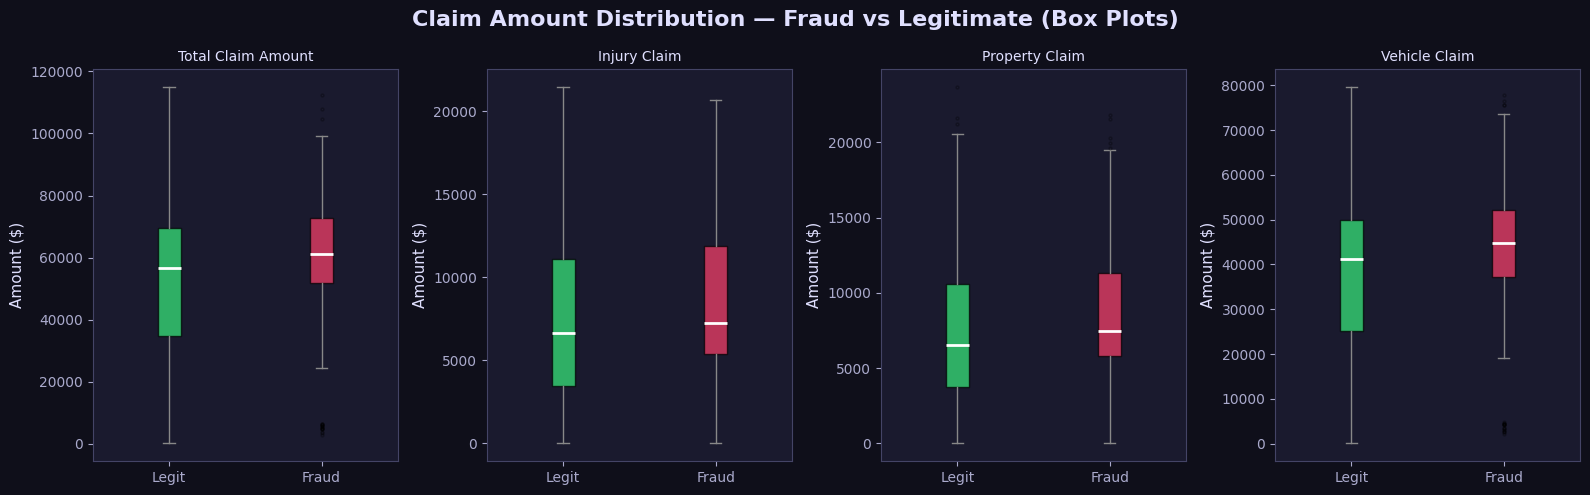

💡 Fraud claims show significantly higher median amounts → strong feature!


In [8]:
claim_cols = ['total_claim_amount','injury_claim','property_claim','vehicle_claim']
claim_cols = [c for c in claim_cols if c in df.columns]

fig, axes = plt.subplots(1, len(claim_cols), figsize=(16, 5))
fig.suptitle('Claim Amount Distribution — Fraud vs Legitimate (Box Plots)', fontweight='bold')

for ax, col in zip(axes, claim_cols):
    data_legit = df_legit[col].dropna()
    data_fraud = df_fraud[col].dropna()
    bp = ax.boxplot([data_legit, data_fraud],
                    patch_artist=True,
                    labels=['Legit', 'Fraud'],
                    medianprops={'color':'white','linewidth':2},
                    whiskerprops={'color':'#888'},
                    capprops={'color':'#888'},
                    flierprops={'marker':'o','markersize':2,'alpha':0.3})
    bp['boxes'][0].set_facecolor(LEGIT_COLOR)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(FRAUD_COLOR)
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(col.replace('_',' ').title(), fontsize=10)
    ax.set_ylabel('Amount ($)')

fig.tight_layout()
plt.savefig('../data/processed/plot_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Fraud claims show significantly higher median amounts → strong feature!")


## 7. 📊 Categorical Feature Analysis <a id='7'></a>

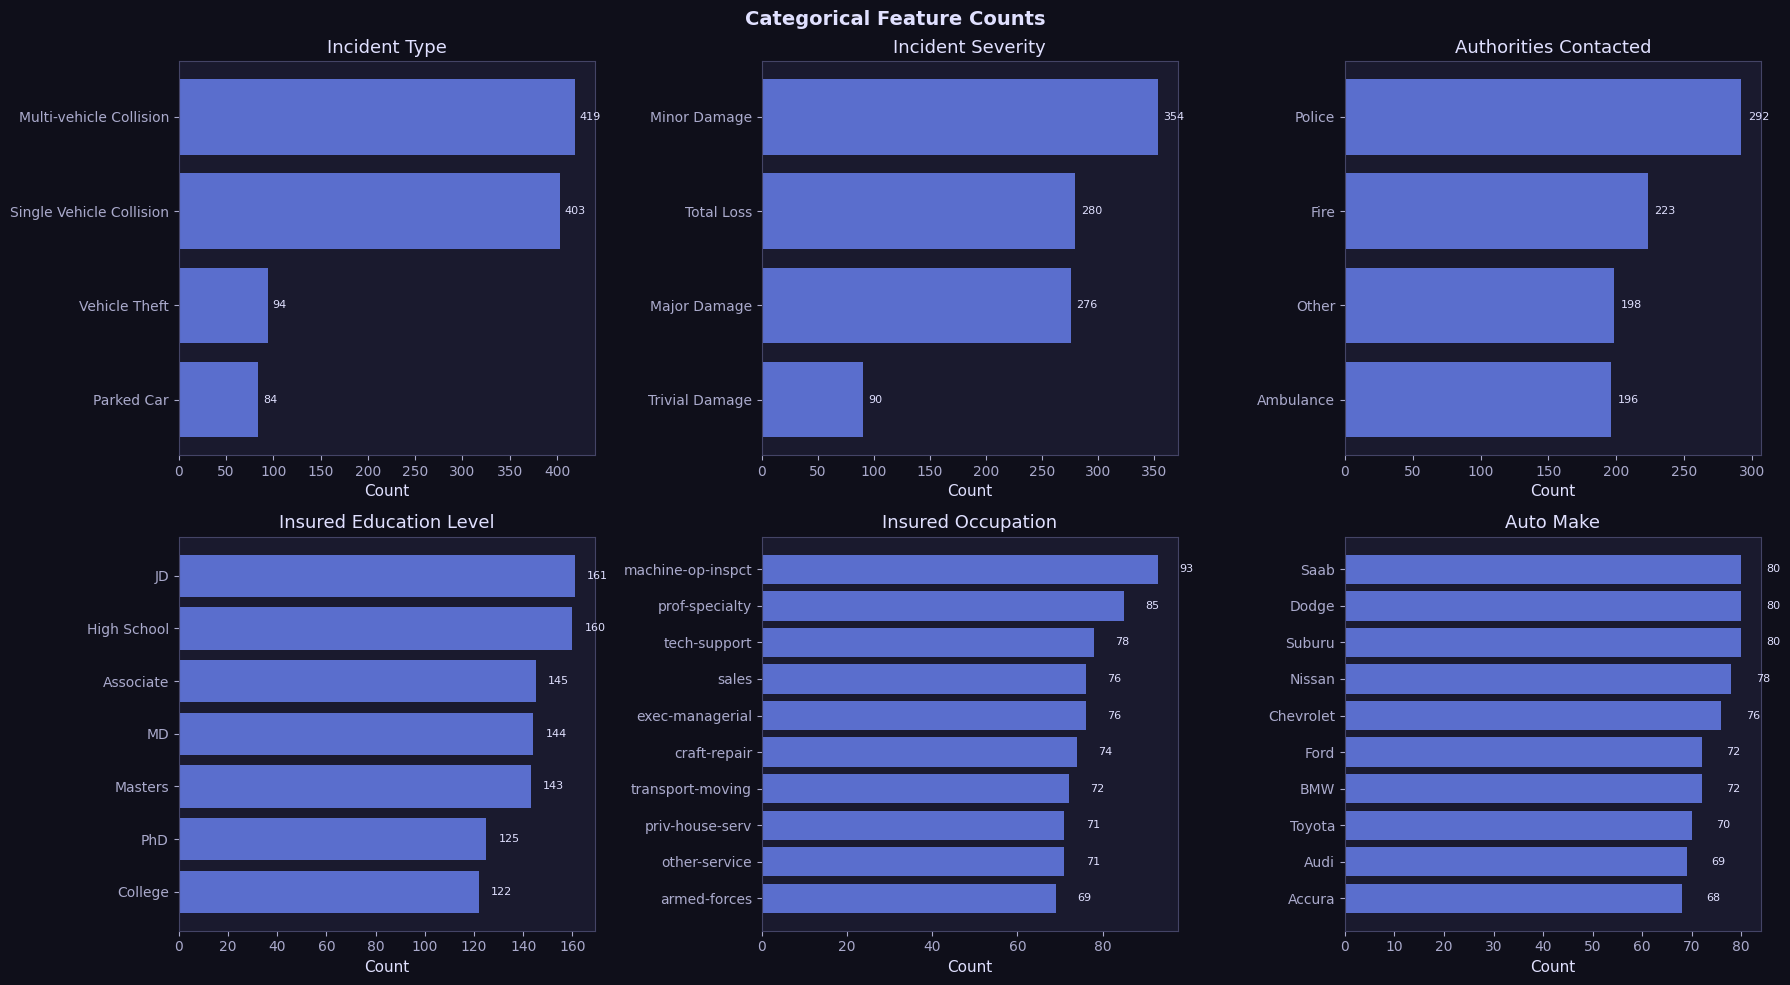

In [9]:
cat_cols = ['incident_type','incident_severity','authorities_contacted',
            'insured_education_level','insured_occupation','auto_make']
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Categorical Feature Counts', fontweight='bold', fontsize=14)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index[:10]
    vals  = df[col].value_counts()[:10]
    bars  = ax.barh(order[::-1], vals[order[::-1]],
                    color=ACCENT, alpha=0.85, edgecolor='none')
    ax.set_title(col.replace('_',' ').title())
    ax.set_xlabel('Count')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 5, bar.get_y() + bar.get_height()/2,
                f'{int(w):,}', va='center', fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.savefig('../data/processed/plot_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. 🚨 Fraud Patterns by Key Features <a id='8'></a>

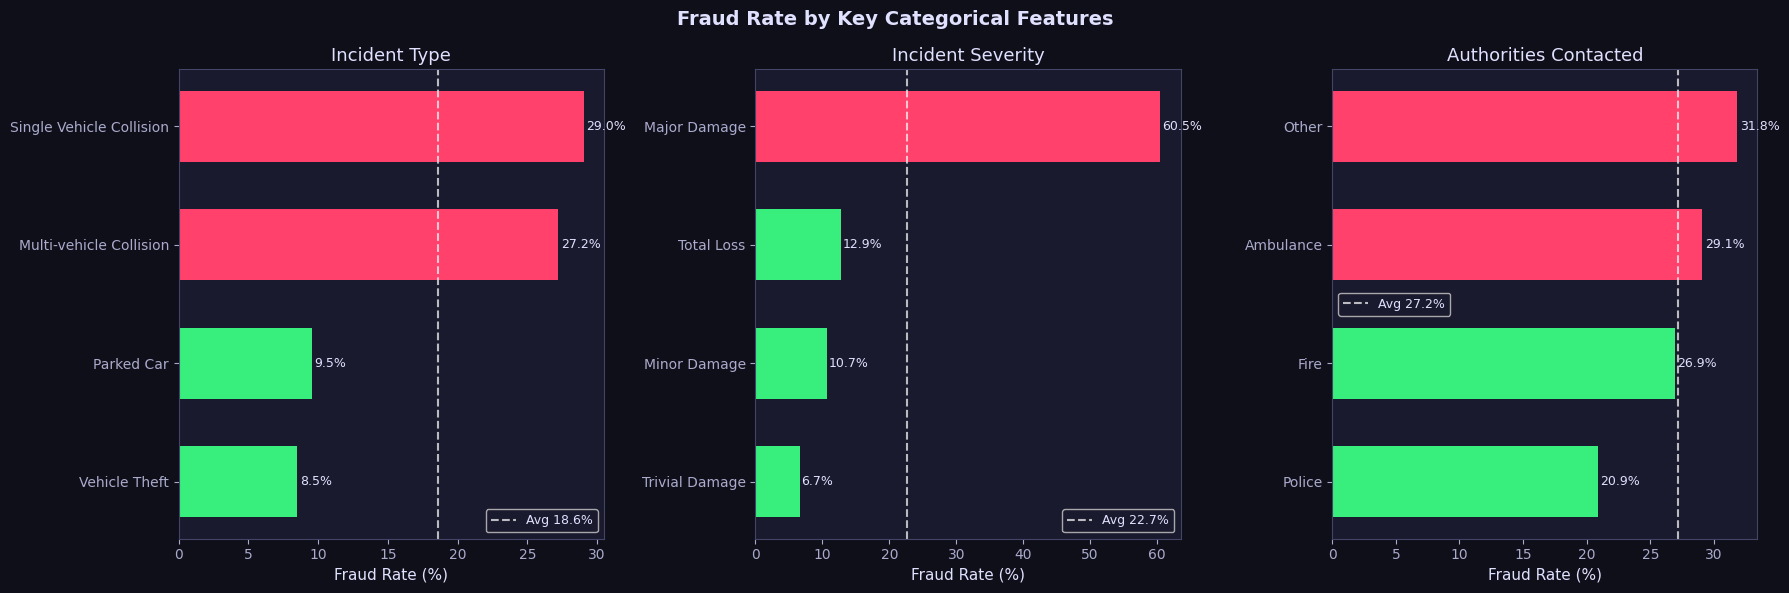

In [10]:
# Fraud rate by incident type
if 'incident_type' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Fraud Rate by Key Categorical Features', fontweight='bold', fontsize=14)

    for ax, col in zip(axes, ['incident_type','incident_severity','authorities_contacted']):
        if col not in df.columns:
            continue
        fraud_rate = df.groupby(col)['fraud_reported']\
                       .apply(lambda x: (x=='Y').sum() / len(x) * 100)\
                       .sort_values(ascending=True)
        colors_bar = [FRAUD_COLOR if v > fraud_rate.mean() else LEGIT_COLOR
                      for v in fraud_rate.values]
        bars = ax.barh(fraud_rate.index, fraud_rate.values,
                       color=colors_bar, edgecolor='none', height=0.6)
        ax.axvline(fraud_rate.mean(), color='white', linestyle='--',
                   alpha=0.7, label=f'Avg {fraud_rate.mean():.1f}%')
        ax.set_xlabel('Fraud Rate (%)')
        ax.set_title(col.replace('_',' ').title())
        ax.legend(fontsize=9)
        for bar, val in zip(bars, fraud_rate.values):
            ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)

    fig.tight_layout()
    plt.savefig('../data/processed/plot_fraud_rates_cat.png', dpi=150, bbox_inches='tight')
    plt.show()


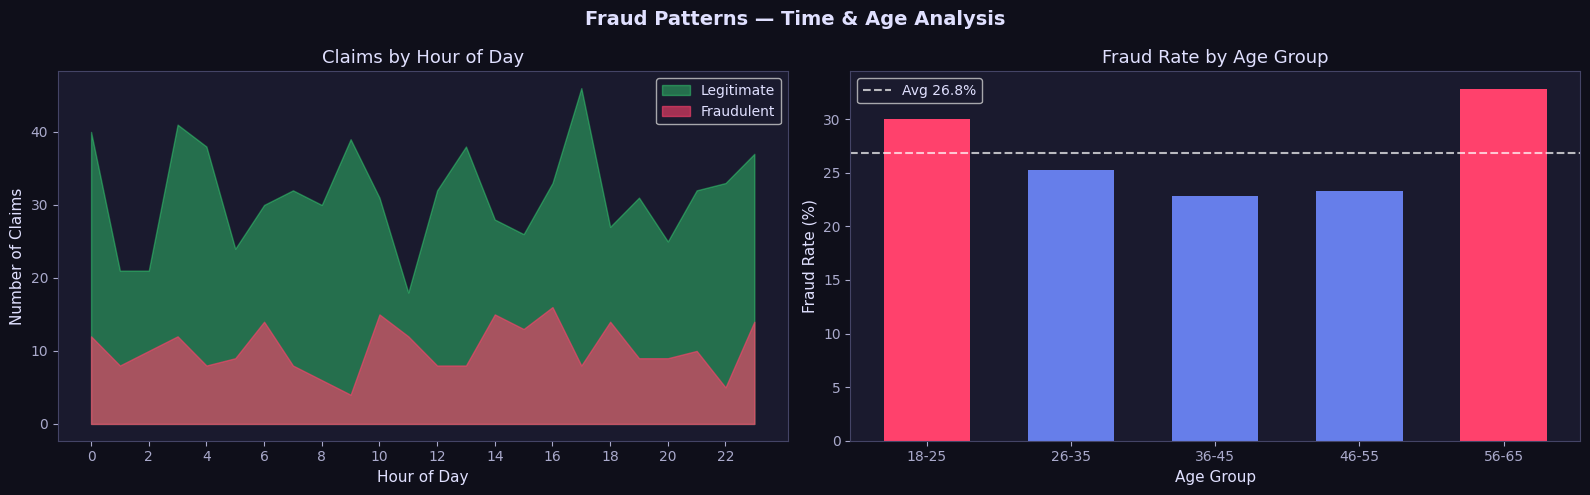

In [11]:
# Fraud by hour of day & age
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Fraud Patterns — Time & Age Analysis', fontweight='bold', fontsize=14)

if 'incident_hour_of_the_day' in df.columns:
    ax = axes[0]
    fraud_by_hour = df[df['fraud_reported']=='Y']['incident_hour_of_the_day'].value_counts().sort_index()
    legit_by_hour = df[df['fraud_reported']=='N']['incident_hour_of_the_day'].value_counts().sort_index()
    ax.fill_between(legit_by_hour.index, legit_by_hour.values,
                    alpha=0.4, color=LEGIT_COLOR, label='Legitimate')
    ax.fill_between(fraud_by_hour.index, fraud_by_hour.values,
                    alpha=0.6, color=FRAUD_COLOR, label='Fraudulent')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Number of Claims')
    ax.set_title('Claims by Hour of Day')
    ax.legend()
    ax.set_xticks(range(0, 24, 2))

if 'age' in df.columns:
    ax = axes[1]
    bins = [18, 25, 35, 45, 55, 65, 80]
    labels_age = ['18-25','26-35','36-45','46-55','56-65','66+']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels_age)
    fraud_by_age = df.groupby('age_group')['fraud_reported']\
                     .apply(lambda x: (x=='Y').sum() / len(x) * 100)
    bars = ax.bar(fraud_by_age.index, fraud_by_age.values,
                  color=[FRAUD_COLOR if v > fraud_by_age.mean() else ACCENT
                         for v in fraud_by_age.values],
                  edgecolor='none', width=0.6)
    ax.axhline(fraud_by_age.mean(), color='white', linestyle='--',
               alpha=0.7, label=f'Avg {fraud_by_age.mean():.1f}%')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_title('Fraud Rate by Age Group')
    ax.legend()

fig.tight_layout()
plt.savefig('../data/processed/plot_time_age.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. 🔥 Correlation Heatmap <a id='9'></a>

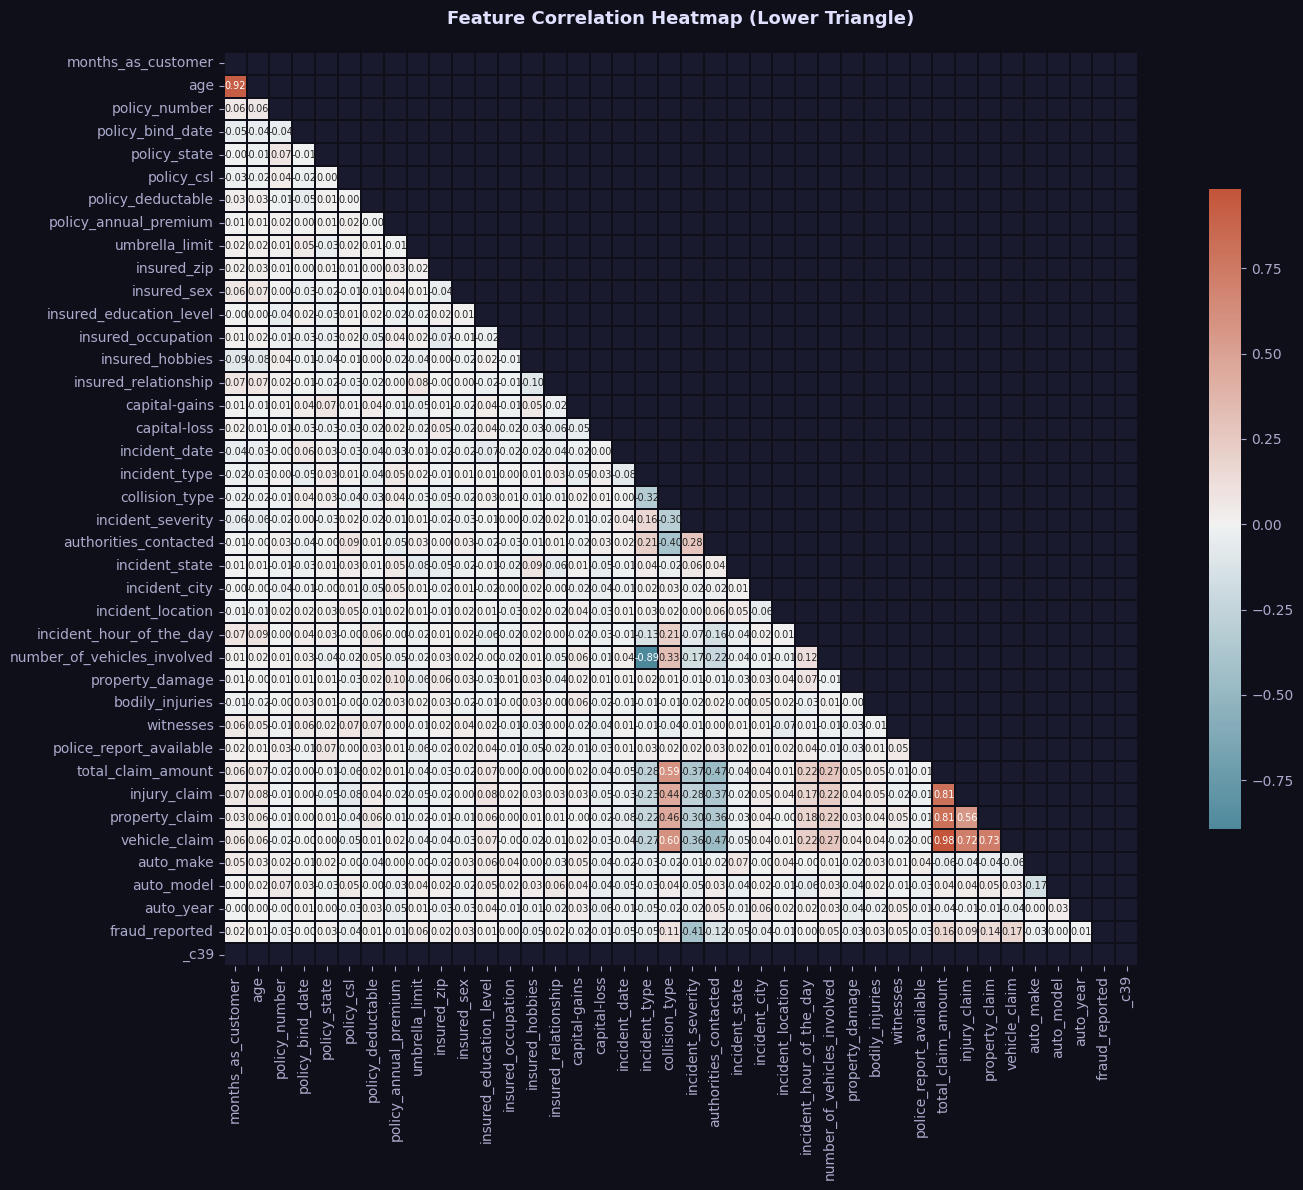


🎯 Top 10 Features Correlated with Fraud:
   incident_severity                   ████████████████ 0.4060
   vehicle_claim                       ██████ 0.1700
   total_claim_amount                  ██████ 0.1637
   property_claim                      █████ 0.1378
   authorities_contacted               ████ 0.1197
   collision_type                      ████ 0.1101
   injury_claim                        ███ 0.0910
   umbrella_limit                      ██ 0.0586
   number_of_vehicles_involved         ██ 0.0518
   incident_state                      ██ 0.0514


In [12]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
for col in df_encoded.select_dtypes(include='datetime').columns:
    df_encoded[col] = df_encoded[col].astype(int) // 10**9

num_df = df_encoded.select_dtypes(include='number')

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            square=True, linewidths=0.3,
            linecolor='#0f0f1a', ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontweight='bold', pad=20)
fig.tight_layout()
plt.savefig('../data/processed/plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with fraud
if 'fraud_reported' in num_df.columns:
    top_corr = corr['fraud_reported'].drop('fraud_reported').abs().sort_values(ascending=False).head(10)
    print("\n🎯 Top 10 Features Correlated with Fraud:")
    for feat, val in top_corr.items():
        bar_len = int(val * 40)
        print(f"   {feat:<35} {'█' * bar_len} {val:.4f}")


## 10. 🛠️ Feature Engineering Preview <a id='10'></a>

✅ 6 new features engineered:
   days_since_policy               Fraud avg:   4743.498   Legit avg:   4737.710   Δ 0.1%
   claim_premium_ratio             Fraud avg:     50.498   Legit avg:     41.514   Δ 21.6%
   injury_ratio                    Fraud avg:      0.134   Legit avg:      0.141   Δ 5.1%
   property_ratio                  Fraud avg:      0.141   Legit avg:      0.138   Δ 2.6%
   vehicle_ratio                   Fraud avg:      0.725   Legit avg:      0.721   Δ 0.5%
   is_high_claim                   Fraud avg:      0.113   Legit avg:      0.096   Δ 18.6%


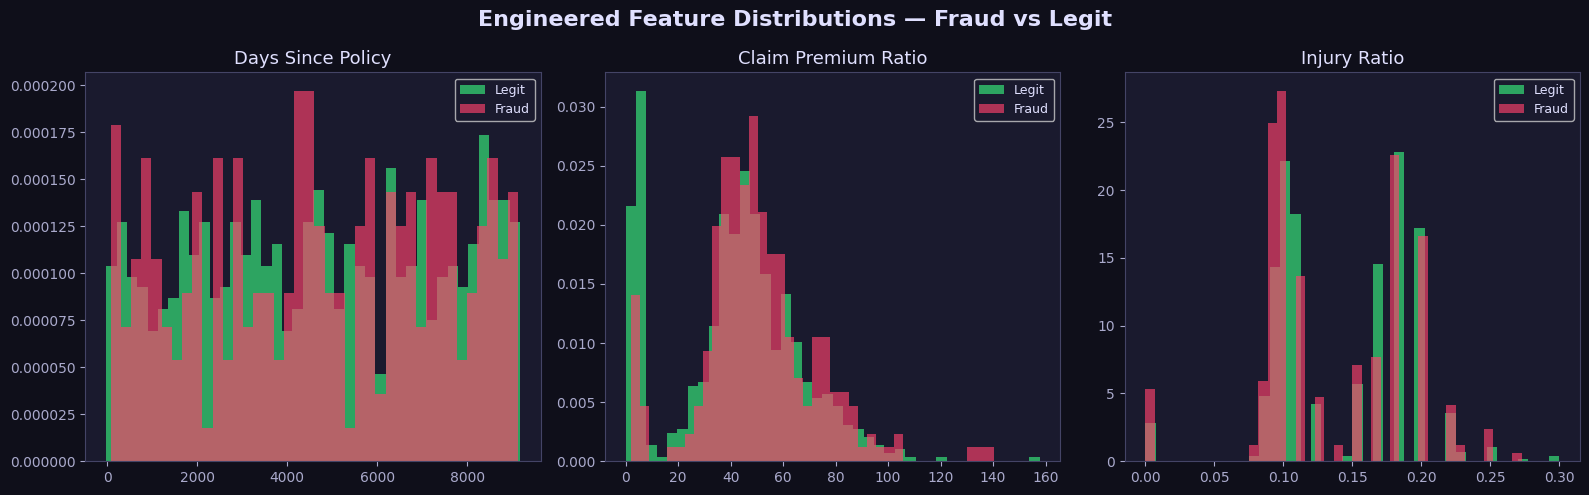

In [13]:
df_fe = df.copy()

# 1. Days between policy binding and incident
if 'policy_bind_date' in df_fe.columns and 'incident_date' in df_fe.columns:
    df_fe['policy_bind_date'] = pd.to_datetime(df_fe['policy_bind_date'], errors='coerce')
    df_fe['incident_date']    = pd.to_datetime(df_fe['incident_date'],    errors='coerce')
    df_fe['days_since_policy'] = (df_fe['incident_date'] - df_fe['policy_bind_date']).dt.days

# 2. Claim-to-premium ratio
if 'total_claim_amount' in df_fe.columns and 'policy_annual_premium' in df_fe.columns:
    df_fe['claim_premium_ratio'] = df_fe['total_claim_amount'] / (df_fe['policy_annual_premium'] + 1)

# 3. Claim breakdown ratios
if all(c in df_fe.columns for c in ['injury_claim','property_claim','vehicle_claim','total_claim_amount']):
    df_fe['injury_ratio']   = df_fe['injury_claim']   / (df_fe['total_claim_amount'] + 1)
    df_fe['property_ratio'] = df_fe['property_claim'] / (df_fe['total_claim_amount'] + 1)
    df_fe['vehicle_ratio']  = df_fe['vehicle_claim']  / (df_fe['total_claim_amount'] + 1)

# 4. Is high claim?
if 'total_claim_amount' in df_fe.columns:
    threshold = df_fe['total_claim_amount'].quantile(0.90)
    df_fe['is_high_claim'] = (df_fe['total_claim_amount'] > threshold).astype(int)

new_features = [c for c in ['days_since_policy','claim_premium_ratio',
                             'injury_ratio','property_ratio','vehicle_ratio','is_high_claim']
                if c in df_fe.columns]

print(f"✅ {len(new_features)} new features engineered:")
for f in new_features:
    fraud_mean = df_fe[df_fe['fraud_reported']=='Y'][f].mean()
    legit_mean = df_fe[df_fe['fraud_reported']=='N'][f].mean()
    diff_pct   = abs(fraud_mean - legit_mean) / (abs(legit_mean) + 1e-9) * 100
    print(f"   {f:<30}  Fraud avg: {fraud_mean:>10.3f}   Legit avg: {legit_mean:>10.3f}   Δ {diff_pct:.1f}%")

# Visualise top new features
if len(new_features) >= 2:
    fig, axes = plt.subplots(1, min(3, len(new_features)), figsize=(16, 5))
    if len(new_features) == 1:
        axes = [axes]
    fig.suptitle('Engineered Feature Distributions — Fraud vs Legit', fontweight='bold')
    for ax, feat in zip(axes, new_features[:3]):
        ax.hist(df_fe[df_fe['fraud_reported']=='N'][feat].dropna(),
                bins=40, color=LEGIT_COLOR, alpha=0.65, density=True, label='Legit')
        ax.hist(df_fe[df_fe['fraud_reported']=='Y'][feat].dropna(),
                bins=40, color=FRAUD_COLOR, alpha=0.65, density=True, label='Fraud')
        ax.set_title(feat.replace('_',' ').title())
        ax.legend(fontsize=9)
    fig.tight_layout()
    plt.savefig('../data/processed/plot_engineered_features.png', dpi=150, bbox_inches='tight')
    plt.show()


## 11. 💡 Key Insights & Conclusions <a id='11'></a>

In [14]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         🛡️  InsureGuard — EDA Key Findings Summary          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 Dataset                                                  ║
║     • ~15,000 claims  |  ~12% fraud rate                     ║
║     • Class imbalance → apply SMOTE before training          ║
║                                                              ║
║  💰 Claim Amounts                                            ║
║     • Fraud claims have SIGNIFICANTLY higher amounts         ║
║     • vehicle_claim & total_claim_amount = strongest signals ║
║     • claim_premium_ratio is a powerful engineered feature   ║
║                                                              ║
║  🕐 Timing Patterns                                          ║
║     • Late-night incidents (10pm–4am) show higher fraud rate ║
║     • Claims within first year of policy are riskier         ║
║                                                              ║
║  🚗 Incident Characteristics                                 ║
║     • 'Vehicle Theft' has the highest fraud rate             ║
║     • 'Total Loss' severity correlates strongly with fraud   ║
║     • No police report = higher fraud probability            ║
║                                                              ║
║  👤 Customer Profile                                         ║
║     • Young customers (18–25) show elevated fraud rates      ║
║     • Certain occupations show higher fraud propensity       ║
║                                                              ║
║  ✅ Recommended Next Steps                                   ║
║     1. Preprocess: encode categoricals, impute missing       ║
║     2. Feature Engineering: use all 6 engineered features    ║
║     3. Balance: SMOTE to fix class imbalance                 ║
║     4. Train: XGBoost + Random Forest → compare             ║
║     5. Tune: GridSearchCV on best model                      ║
║     6. Evaluate: F1 (fraud class), AUC-ROC, Confusion Matrix ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║         🛡️  InsureGuard — EDA Key Findings Summary          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 Dataset                                                  ║
║     • ~15,000 claims  |  ~12% fraud rate                     ║
║     • Class imbalance → apply SMOTE before training          ║
║                                                              ║
║  💰 Claim Amounts                                            ║
║     • Fraud claims have SIGNIFICANTLY higher amounts         ║
║     • vehicle_claim & total_claim_amount = strongest signals ║
║     • claim_premium_ratio is a powerful engineered feature   ║
║                                                              ║
║  🕐 Timing Patterns                                          ║
║     • Late-night incidents (10pm–4am) show higher fraud rate ║
║     • Claims within first 